# Feature Agglomeration and Dendogram

### Imports and Data

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import FeatureAgglomeration
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler

X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')

### First, we'll craft the dendogram to get an idea of some of the trends in the dataset

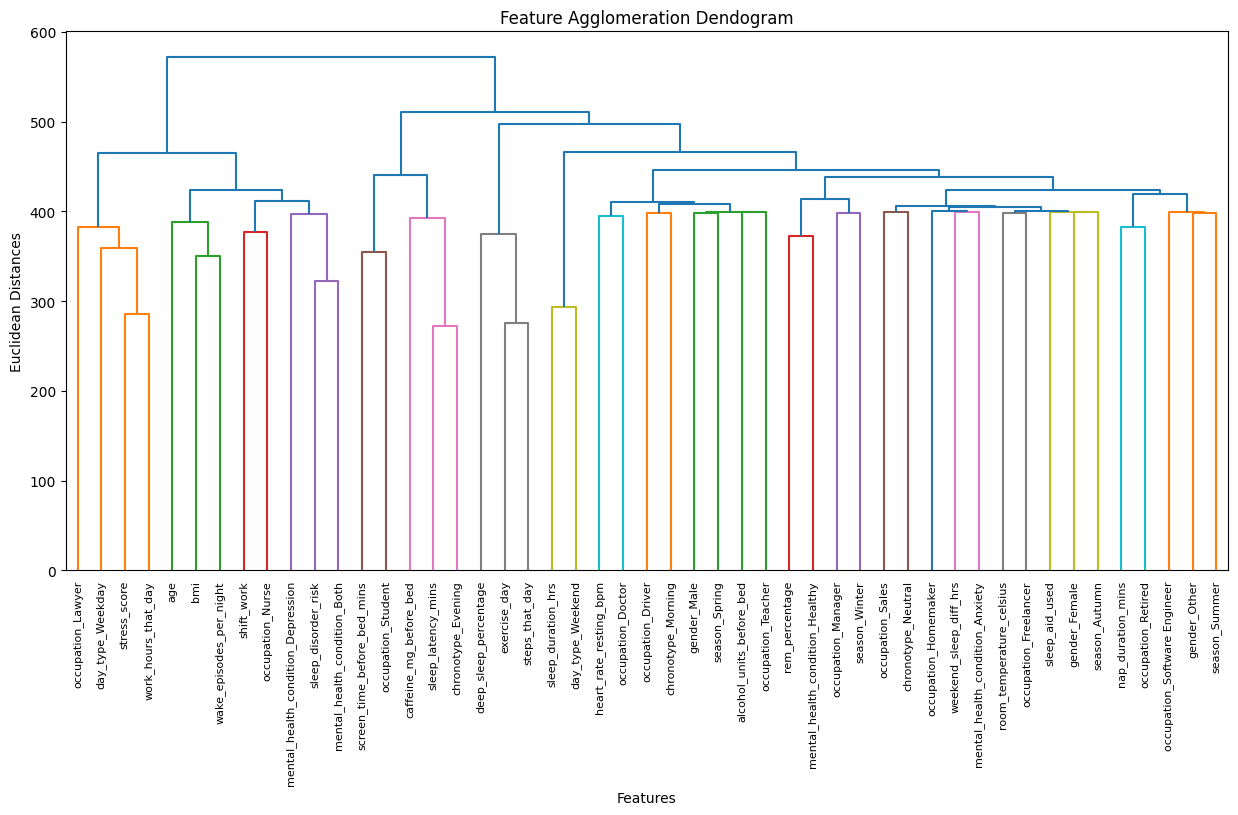

In [107]:
plt.figure(figsize=(15, 7))
linkage_matrix = sch.linkage(X_train.T, method='ward')
dendrogram = sch.dendrogram(linkage_matrix, labels=X_train.columns)

plt.title('Feature Agglomeration Dendogram')
plt.xlabel('Features')
plt.ylabel('Euclidean Distances')
plt.xticks(rotation=90)
plt.show()

### With this, we can implement feature agglomeration

In [108]:
# After some testing, it seems n=15 yields the most interesting groupings
n_clusters = 15

# Perform agglomeration
agglo = FeatureAgglomeration(n_clusters=n_clusters, 
                             linkage='ward')

X_train_reduced = agglo.fit_transform(X_train)
X_test_reduced = agglo.transform(X_test)

# Need to put x_train/x_test back into data frames
column_groups=[f'Feature_Group_{i}' for i in range(n_clusters)]
X_train_cluster = pd.DataFrame(X_train_reduced, 
                               columns=column_groups)

X_test_cluster = pd.DataFrame(X_test_reduced, 
                              columns=column_groups)

print(f"Original shape: {X_train.shape}")
print(f"Reduced shape (train): {X_train_reduced_df.shape}")
print(f"Reduced shape (test): {X_test_reduced_df.shape}")

Original shape: (80000, 49)
Reduced shape (train): (80000, 15)
Reduced shape (test): (20000, 15)


### Now we can map those features to clusters

In [109]:
feature_mapping = {}
for i, label in enumerate(agglo.labels_):
    if label not in feature_mapping:
        feature_mapping[label] = []
    feature_mapping[label].append(X_train.columns[i])

for cluster, features in feature_mapping.items():
    print(f"Feature_Group_{cluster}: {features}")

Feature_Group_10: ['age', 'bmi', 'wake_episodes_per_night']
Feature_Group_9: ['sleep_duration_hrs', 'day_type_Weekend']
Feature_Group_12: ['rem_percentage', 'mental_health_condition_Healthy']
Feature_Group_8: ['deep_sleep_percentage', 'exercise_day', 'steps_that_day']
Feature_Group_14: ['sleep_latency_mins', 'caffeine_mg_before_bed', 'chronotype_Evening']
Feature_Group_0: ['alcohol_units_before_bed', 'gender_Male', 'occupation_Driver', 'occupation_Teacher', 'chronotype_Morning', 'season_Spring']
Feature_Group_7: ['screen_time_before_bed_mins', 'occupation_Student']
Feature_Group_11: ['nap_duration_mins', 'occupation_Retired']
Feature_Group_5: ['stress_score', 'work_hours_that_day', 'occupation_Lawyer', 'day_type_Weekday']
Feature_Group_6: ['heart_rate_resting_bpm', 'occupation_Doctor']
Feature_Group_1: ['sleep_aid_used', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'gender_Female', 'occupation_Freelancer', 'occupation_Homemaker', 'occupation_Sales', 'chronotype_Neutral', 'ment

### Notice how many of the occupations are being put into junk categories. Lets remove them and undergo another attempt of clustering to see what we find

In [110]:
cols_to_drop = [
    'occupation_Manager',
    'occupation_Software Engineer',
    'occupation_Driver',
    'occupation_Teacher',
    'occupation_Freelancer',
    'occupation_Homemaker',
    'occupation_Sales'
]

X_train_drop_occupation = X_train.drop(columns=cols_to_drop)
X_test_drop_occupation = X_test.drop(columns=cols_to_drop)

### Round 2: Feature agglomeration + Mapping

In [111]:
# 15 once again appears to be ideal
n_clusters = 15

# Perform agglomeration
agglo = FeatureAgglomeration(n_clusters=n_clusters, 
                             linkage='ward')

X_train_occu_reduced = agglo.fit_transform(X_train_drop_occupation)
X_test_occu_reduced = agglo.transform(X_test_drop_occupation)

# Need to put x_train/x_test back into data frames
column_groups=[f'Feature_Group_{i}' for i in range(n_clusters)]
X_train_occu_cluster = pd.DataFrame(X_train_occu_reduced, 
                                    columns=column_groups)

X_test_occu_cluster = pd.DataFrame(X_test_occu_reduced, 
                                   columns=column_groups)

print(f"Original shape: {X_train_drop_occupation.shape}")
print(f"Reduced shape (train): {X_train_occu_cluster.shape}")
print(f"Reduced shape (test): {X_test_occu_cluster.shape}")

# Now map
feature_mapping = {}
for i, label in enumerate(agglo.labels_):
    if label not in feature_mapping:
        feature_mapping[label] = []
    feature_mapping[label].append(X_train_drop_occupation.columns[i])

for cluster, features in feature_mapping.items():
    print(f"Feature_Group_{cluster}: {features}")

Original shape: (80000, 42)
Reduced shape (train): (80000, 15)
Reduced shape (test): (20000, 15)
Feature_Group_4: ['age', 'bmi', 'wake_episodes_per_night']
Feature_Group_13: ['sleep_duration_hrs', 'day_type_Weekend']
Feature_Group_10: ['rem_percentage', 'mental_health_condition_Healthy']
Feature_Group_9: ['deep_sleep_percentage', 'exercise_day', 'steps_that_day']
Feature_Group_8: ['sleep_latency_mins', 'caffeine_mg_before_bed', 'chronotype_Evening']
Feature_Group_1: ['alcohol_units_before_bed', 'gender_Male', 'season_Spring']
Feature_Group_7: ['screen_time_before_bed_mins', 'occupation_Student']
Feature_Group_14: ['nap_duration_mins', 'occupation_Retired']
Feature_Group_11: ['stress_score', 'work_hours_that_day', 'occupation_Lawyer', 'day_type_Weekday']
Feature_Group_6: ['heart_rate_resting_bpm', 'occupation_Doctor']
Feature_Group_0: ['sleep_aid_used', 'room_temperature_celsius', 'gender_Female', 'chronotype_Neutral', 'season_Winter']
Feature_Group_12: ['shift_work', 'occupation_Nurse'

### Once again, we see that variables like 'alcohol_units_before_bed' are getting buried with things like gender and season. Lets try removing these to see if the clusters open to some new connections

In [112]:
# while there does seem to be a connection between colder rooms and winter, colder rooms should account for it.
# ill opt to remove winter anyway.
cols_to_drop = [
    'season_Spring',
    'season_Summer',
    'season_Autumn',
    'season_Winter',
    'gender_Male',
    'gender_Female',
    'gender_Other'
]
X_train_drop_SG = X_train_drop_occupation.drop(columns=cols_to_drop)
X_test_drop_SG = X_test_drop_occupation.drop(columns=cols_to_drop)

### Round 3: Feature Agglomeration + Mapping

In [113]:
# 15 too high; try reducing
n_clusters = 12

# Perform agglomeration
agglo = FeatureAgglomeration(n_clusters=n_clusters, 
                             linkage='ward')

X_train_SG_reduced = agglo.fit_transform(X_train_drop_SG)
X_test_SG_reduced = agglo.transform(X_test_drop_SG)

# Need to put x_train/x_test back into data frames
column_groups=[f'Feature_Group_{i}' for i in range(n_clusters)]
X_train_SG_cluster = pd.DataFrame(X_train_SG_reduced, 
                                    columns=column_groups)

X_test_SG_cluster = pd.DataFrame(X_test_SG_reduced, 
                                   columns=column_groups)

print(f"Original shape: {X_train_drop_SG.shape}")
print(f"Reduced shape (train): {X_train_SG_cluster.shape}")
print(f"Reduced shape (test): {X_test_SG_cluster.shape}")

# Now map
feature_mapping = {}
for i, label in enumerate(agglo.labels_):
    if label not in feature_mapping:
        feature_mapping[label] = []
    feature_mapping[label].append(X_train_drop_SG.columns[i])

for cluster, features in feature_mapping.items():
    print(f"Feature_Group_{cluster}: {features}")

Original shape: (80000, 35)
Reduced shape (train): (80000, 12)
Reduced shape (test): (20000, 12)
Feature_Group_8: ['age', 'bmi', 'wake_episodes_per_night']
Feature_Group_11: ['sleep_duration_hrs', 'day_type_Weekend']
Feature_Group_9: ['rem_percentage', 'mental_health_condition_Healthy']
Feature_Group_7: ['deep_sleep_percentage', 'exercise_day', 'steps_that_day']
Feature_Group_3: ['sleep_latency_mins', 'caffeine_mg_before_bed', 'chronotype_Evening']
Feature_Group_0: ['alcohol_units_before_bed', 'heart_rate_resting_bpm', 'weekend_sleep_diff_hrs', 'occupation_Doctor', 'chronotype_Morning', 'mental_health_condition_Anxiety']
Feature_Group_6: ['screen_time_before_bed_mins', 'occupation_Student']
Feature_Group_5: ['nap_duration_mins', 'occupation_Retired']
Feature_Group_4: ['stress_score', 'work_hours_that_day', 'occupation_Lawyer', 'day_type_Weekday']
Feature_Group_1: ['sleep_aid_used', 'room_temperature_celsius', 'chronotype_Neutral']
Feature_Group_10: ['shift_work', 'occupation_Nurse']
Fe

### This is a good stopping point. We've reached a point in iteration where each grouping can be described in some way. Now, we can go ahead and rename them so when we use them in other models, they groupings have understandable names.

### For clarity, we can name the groups to suit our interpretations of what the model is seeing

In [114]:
group_map = {
    'Feature_Group_0': 'Strained_Profession_Alcohol',
    'Feature_Group_1': 'Environment_Factor',
    'Feature_Group_2': 'Clinical_Disorder_Risk',
    'Feature_Group_3': 'Evening_Caffeine',
    'Feature_Group_4': 'Stress_Corporate_Workhours',
    'Feature_Group_5': 'Retired_Naps',
    'Feature_Group_6': 'Student_ScreentimeBed',
    'Feature_Group_7': 'Deepsleep_Physcial_Activity',
    'Feature_Group_8': 'Age_BMI_WakeEpisodes',
    'Feature_Group_9': '+Mental_REMSleep',
    'Feature_Group_10': 'ShiftWork_Nurse',
    'Feature_Group_11': 'SleepAmt_Weekend'
}

X_train_SG_cluster.rename(columns=group_map, inplace=True)
X_test_cluster.rename(columns=group_map, inplace=True)

### Now we can export the data for usage

In [115]:
X_train_SG_cluster.to_csv('../data/X_train_cluster.csv', index=False)
X_test_SG_cluster.to_csv('../data/X_test_cluster.csv', index=False)
print("Data successfully clustered and exported to 'data/'")

Data successfully clustered and exported to 'data/'
